**Tomato Crop Disease Detection in Kenya**

1. Data Preparation & Preprocessing

In [14]:
# Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import copy
import kagglehub

In [15]:
# Set Device (GPU or CPU)
# This will ensure we use the GPU if it's available, which is highly recommended for training deep learning models.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [16]:
# Define Data Transforms and Load Datasets
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/kaggle/input/tomatoleaf/tomato'
train_data_dir = os.path.join(data_dir, 'train')
val_data_dir = os.path.join(data_dir, 'val')

# Load the full training dataset
full_train_dataset = datasets.ImageFolder(train_data_dir, data_transforms['train'])

# Split the full training dataset into a new training set and a test set
train_size = int(0.8 * len(full_train_dataset)) # e.g., 80% for training
test_size = len(full_train_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, test_size])

# Load the validation dataset from the separate val directory
val_dataset = datasets.ImageFolder(val_data_dir, data_transforms['val'])

# Create DataLoaders
dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4),
    'val': torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4),
    'test': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4) # New test dataloader
}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}

class_names = full_train_dataset.classes

print(f"Training data size: {dataset_sizes['train']}")
print(f"Validation data size: {dataset_sizes['val']}")
print(f"Test data size: {dataset_sizes['test']}")
print(f"Classes: {class_names}")

Training data size: 8000
Validation data size: 1000
Test data size: 2000
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


2. Model Selection & Training

In [17]:
# Model Architecture: Transfer Learning with ResNet-50
model_ft = models.resnet50(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

# Redefine the final fully connected layer to include a Dropout layer
model_ft.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, len(class_names))
)

model_ft = model_ft.to(device)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [19]:
# Model Training Function
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [20]:
# Start Training
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.9384 Acc: 0.6976
val Loss: 0.3446 Acc: 0.8860

Epoch 1/9
----------
train Loss: 0.2919 Acc: 0.9069
val Loss: 0.1518 Acc: 0.9540

Epoch 2/9
----------
train Loss: 0.2066 Acc: 0.9320
val Loss: 0.1296 Acc: 0.9580

Epoch 3/9
----------
train Loss: 0.1642 Acc: 0.9440
val Loss: 0.0993 Acc: 0.9690

Epoch 4/9
----------
train Loss: 0.1443 Acc: 0.9514
val Loss: 0.0882 Acc: 0.9660

Epoch 5/9
----------
train Loss: 0.1344 Acc: 0.9567
val Loss: 0.1026 Acc: 0.9670

Epoch 6/9
----------
train Loss: 0.1267 Acc: 0.9576
val Loss: 0.0970 Acc: 0.9650

Epoch 7/9
----------
train Loss: 0.0996 Acc: 0.9676
val Loss: 0.0808 Acc: 0.9710

Epoch 8/9
----------
train Loss: 0.0988 Acc: 0.9664
val Loss: 0.0815 Acc: 0.9760

Epoch 9/9
----------
train Loss: 0.0885 Acc: 0.9724
val Loss: 0.0685 Acc: 0.9790

Training complete in 7m 49s
Best val Acc: 0.979000


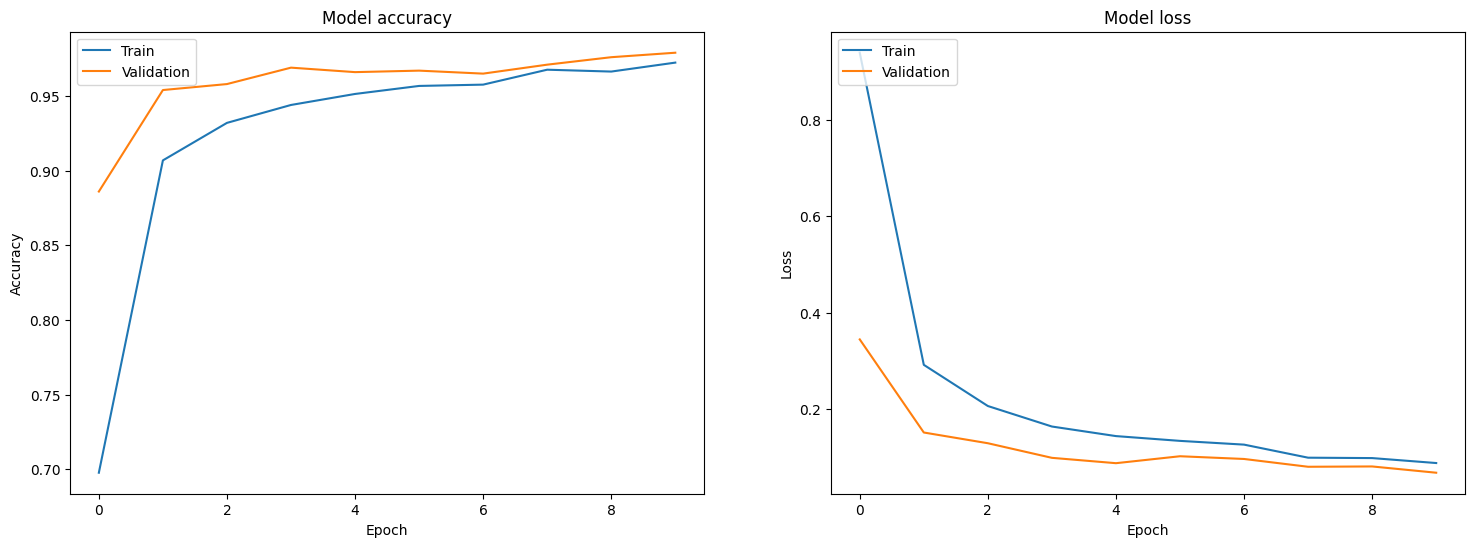

In [21]:
# Plot Training and Validation Loss/Accuracy
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    ax1.plot(history['train_acc'])
    ax1.plot(history['val_acc'])
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')

    ax2.plot(history['train_loss'])
    ax2.plot(history['val_loss'])
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_training_history(history)

3. Model Evaluation & Tuning

In [22]:
# Test the Model on the new Test Set
model_ft.eval()
running_corrects = 0
all_preds = []
all_labels = []

print("Evaluating on test set...")
for inputs, labels in dataloaders['test']:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    running_corrects += torch.sum(preds == labels.data)

test_acc = running_corrects.double() / dataset_sizes['test']
print(f'Test Accuracy: {test_acc:.4f}')

Evaluating on test set...
Test Accuracy: 0.9805


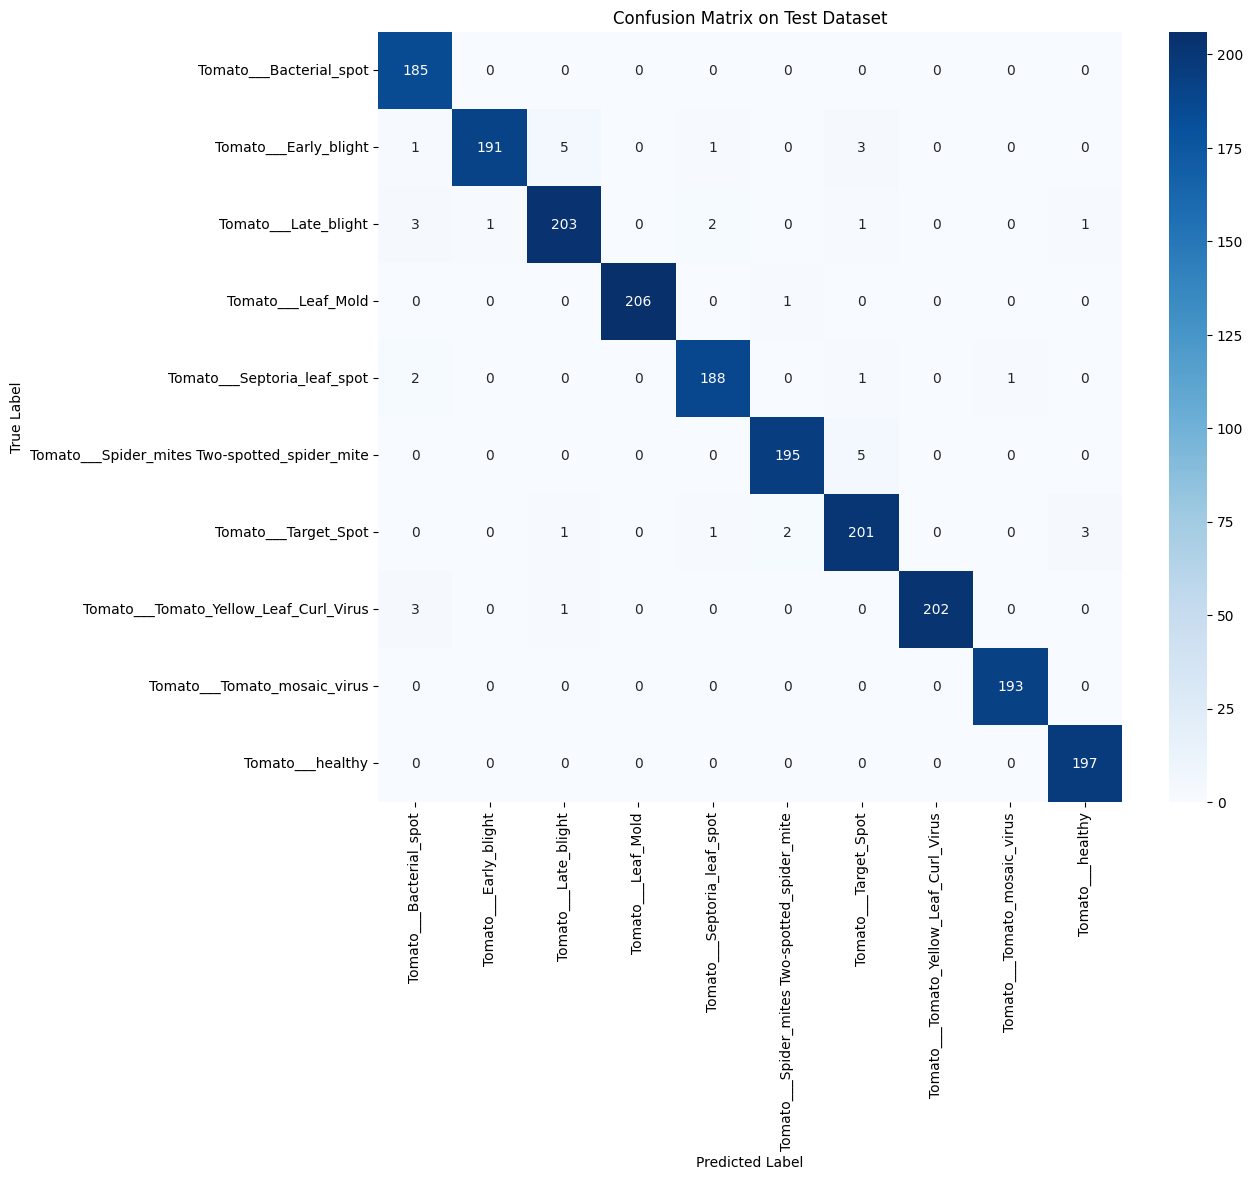

In [23]:
# Generate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

4. Model Saving & Deployment

In [24]:
# Save the Best Model
model_save_path = 'tomato_disease_resnet50_best.pth'
torch.save(model_ft.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to tomato_disease_resnet50_best.pth
